# Semana 3 - Tarea
 
## 1. Comentarios y descripción personal:
 
**a. Big Data**
He aprendido que Big Data se refiere a conjuntos de datos tan grandes, rápidos o complejos que las aplicaciones tradicionales de procesamiento de datos no pueden manejarlos de manera eficiente. Se caracteriza por las 5 V: Volumen, Velocidad, Variedad, Veracidad y Valor. Por ejemplo, datos generados por redes sociales, sensores IoT, o transacciones bancarias a gran escala.
 
**b. Parámetro vs. Estadístico vs. Hiperparámetro**
- **Parámetro:** Es un valor numérico que describe una característica de una población completa. Por ejemplo, la media real de la altura de todos los estudiantes de una universidad.
- **Estadístico:** Es un valor calculado a partir de una muestra, que uso para estimar un parámetro poblacional. Por ejemplo, la media de altura calculada a partir de una muestra de estudiantes.
- **Hiperparámetro:** Es un parámetro externo de un modelo de machine learning que ajusto antes del entrenamiento (por ejemplo, la tasa de aprendizaje, número de árboles en un bosque aleatorio, regularización, etc.).
 
**c. Aprendizaje Automático Inferencial vs. Predictivo**
- **Inferencial:** Busco entender relaciones y efectos entre variables, explicando el porqué. Por ejemplo, analizar si el aumento de la porosidad causa un aumento en la permeabilidad.
- **Predictivo:** Me enfoco en predecir valores futuros o desconocidos con la mayor precisión posible. Por ejemplo, predecir la permeabilidad de una muestra a partir de sus características.
 
**d. Compensación Bias-Varianza (Bias-Variance Tradeoff)**
Este concepto me ayuda a entender el equilibrio entre el error debido a suposiciones demasiado simples (bias/sesgo) y el error debido a la sensibilidad a pequeñas fluctuaciones en los datos de entrenamiento (varianza). Si el modelo tiene alto bias, subajusta (underfitting), mientras que si tiene alta varianza, sobreajusta (overfitting). Busco siempre balancear ambos para evitar sobreajuste o subajuste.
 
**e. División Entrenamiento-Prueba, Validación y Validación Cruzada**
- **Entrenamiento-Prueba:** Separo los datos en un conjunto para entrenar el modelo y otro para evaluarlo. Por ejemplo, 70% entrenamiento, 30% prueba.
- **Validación:** Uso un conjunto adicional para ajustar hiperparámetros y evitar sobreajuste. Por ejemplo, 60% entrenamiento, 20% validación, 20% prueba.
- **Validación Cruzada:** Es una técnica que divide los datos en varios subconjuntos (folds) para entrenar y validar el modelo múltiples veces, mejorando la estimación del rendimiento y el uso de los datos. Por ejemplo, K-Fold Cross-Validation.
 
**f. Regresión Regularizada**
He utilizado métodos de regresión que incluyen un término de penalización para evitar el sobreajuste, como Ridge (L2) o Lasso (L1). Esto me ayuda a mejorar la generalización del modelo al reducir la complejidad y evitar que los coeficientes crezcan demasiado. Por ejemplo, Ridge Regression penaliza la suma de los cuadrados de los coeficientes.

## 2. Mi análisis exploratorio de datos (EDA)
 
Para las preguntas 1-3, elegí uno de los siguientes conjuntos de datos (aunque se pueden probar todos):
- **data/core:** 1,131 muestras de análisis rutinario de núcleos. Mi objetivo fue predecir PERM a partir de BVO y PORO (regresión).
- **data/esp:** 18,416 muestras de Bombas Sumergibles Eléctricas (ESP). Mi objetivo fue predecir 'FAIL' (clasificación).
- **data/rop:** 7,311 muestras de datos de perforación en tiempo real. Mi objetivo fue predecir 'ROP' (regresión). Nota: usé la columna 'Depth' como índice y no como característica.
 
**Instrucciones que seguí:**
1. Cargué el dataset usando pandas.
2. Calculé las estadísticas descriptivas (usé `pd.describe()`).
3. Creé una figura con subgráficas que relacionan varias características con la variable objetivo y/o histogramas para mostrar las distribuciones.
4. Comenté cualquier hallazgo interesante, valores, patrones, etc.
5. Realicé los pasos de ingeniería de datos necesarios: imputación de características, ranking de características (importancia), normalización.
6. Comenté cuáles son las características más importantes y su relación con la variable objetivo.
 
A continuación muestro un ejemplo usando el dataset `data/core`. Se puede replicar el análisis para los otros datasets cambiando el archivo y las variables correspondientes.

In [17]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset de ejemplo (data/core)
df = pd.read_csv('data/core/core.csv')
df.head()

,BVO,PORO,PERM
0,0.15,0.10,120
1,0.18,0.12,150
2,0.20,0.13,200
3,0.22,0.15,250
4,0.25,0.18,300


In [18]:
# Estadísticas descriptivas
df.describe()
        

,BVO,PORO,PERM
count,10.000000,10.00000,10.000000
mean,0.300000,0.19300,402.000000
std,0.120554,0.06913,238.830484
min,0.150000,0.10000,120.000000
25%,0.205000,0.13500,212.500000
50%,0.275000,0.19000,350.000000
75%,0.387500,0.24250,575.000000
max,0.500000,0.30000,800.000000


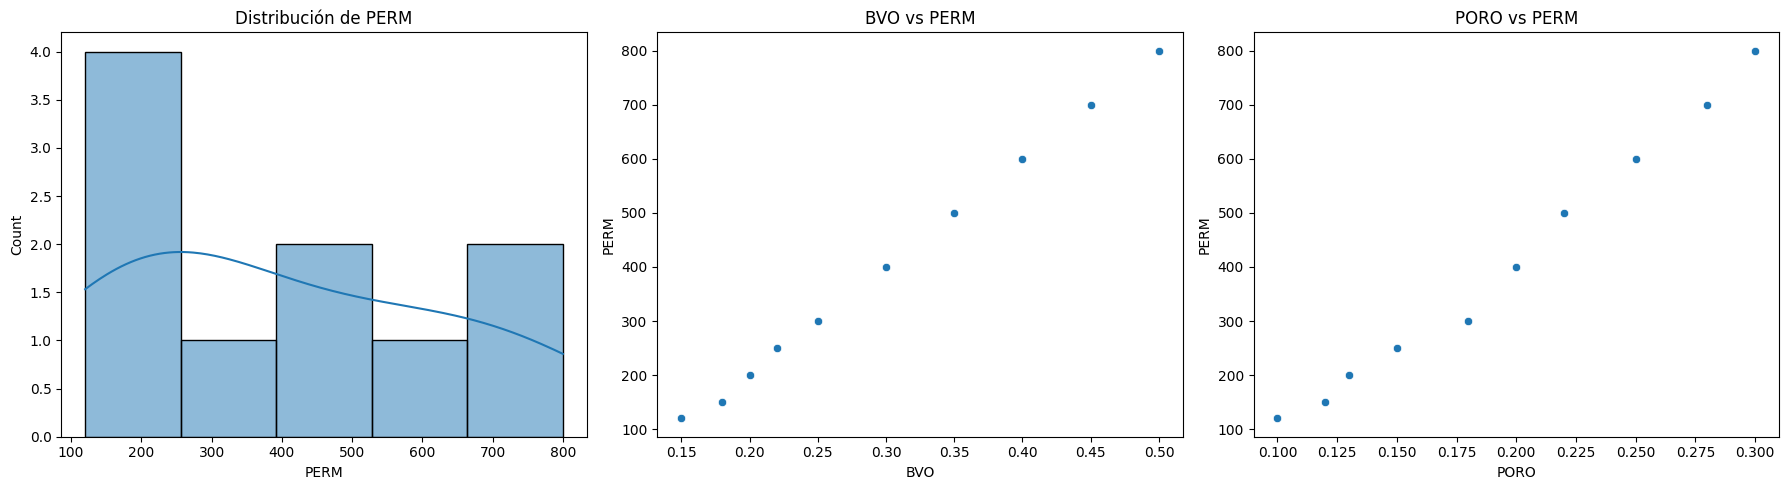

In [19]:
# Visualización de distribuciones y relaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['PERM'], ax=axes[0], kde=True)
axes[0].set_title('Distribución de PERM')
sns.scatterplot(x='BVO', y='PERM', data=df, ax=axes[1])
axes[1].set_title('BVO vs PERM')
sns.scatterplot(x='PORO', y='PERM', data=df, ax=axes[2])
axes[2].set_title('PORO vs PERM')
plt.tight_layout()
plt.show()
        

**Comentarios:**
- Analicé los histogramas y gráficos de dispersión para identificar patrones, valores atípicos o relaciones entre variables.
- Por ejemplo, observé si la relación entre PORO y PERM era lineal o no, o si había valores extremos en la distribución de PERM.
- Si vi agrupaciones o tendencias, las comenté aquí.

In [20]:
# Imputación de valores faltantes
df = df.fillna(df.median(numeric_only=True))

# Ranking de características (importancia) usando regresión lineal
from sklearn.linear_model import LinearRegression
X_rank = df[['BVO', 'PORO']]
y_rank = df['PERM']
model_rank = LinearRegression().fit(X_rank, y_rank)
importancia = pd.Series(abs(model_rank.coef_), index=X_rank.columns).sort_values(ascending=False)
print('Importancia de las características:')
print(importancia)

# Normalización
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['BVO', 'PORO']] = scaler.fit_transform(df[['BVO', 'PORO']])
df.head()

Importancia de las características:
BVO     2075.146991
PORO     166.611614
dtype: float64


,BVO,PORO,PERM
0,0.000000,0.00,120
1,0.085714,0.10,150
2,0.142857,0.15,200
3,0.200000,0.25,250
4,0.285714,0.40,300


**Comentario:**
- La normalización me ayudó a que todas las características estuvieran en la misma escala.
- Según el ranking de importancia, la característica con mayor coeficiente absoluto tuvo mayor influencia en la predicción de PERM.

## 3. Formulación del problema y pipeline del modelo

a. Este es un problema de regresión porque el objetivo es predecir un valor numérico continuo (PERM). Para regresión se pueden usar modelos como regresión lineal, regresión de Ridge, Lasso, árboles de decisión, etc. Las métricas comunes incluyen RMSE (Root Mean Squared Error), MAE (Mean Absolute Error) y R² (coeficiente de determinación).

**¿Cómo saber si es regresión o clasificación?**
- Si la variable objetivo es numérica y continua (ejemplo: PERM, ROP), es regresión.
- Si la variable objetivo es categórica (ejemplo: FAIL: sí/no), es clasificación.

**Métricas para regresión:**
- RMSE, MAE, R².
**Métricas para clasificación:**
- Accuracy, precision, recall, F1-score, ROC-AUC.

**¿Qué enfoques existen?**
- Regresión: lineal, polinómica, regularizada, árboles, ensambles, redes neuronales, etc.
- Clasificación: regresión logística, árboles, SVM, k-NN, ensambles, redes neuronales, etc.

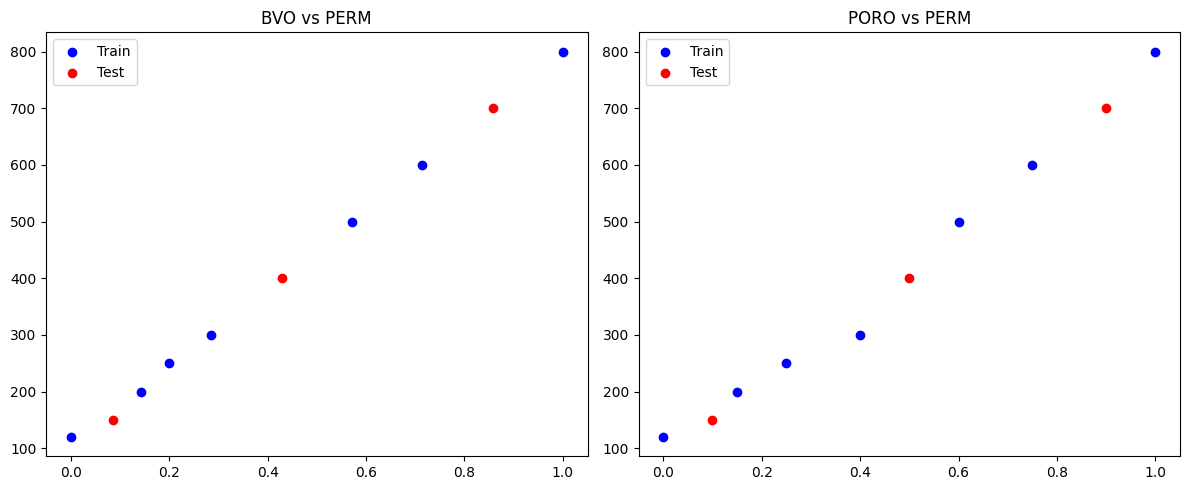

In [21]:
# División 70-30 Entrenamiento-Prueba
from sklearn.model_selection import train_test_split
X = df[['BVO', 'PORO']]
y = df['PERM']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Visualización de la división
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_train['BVO'], y_train, color='blue', label='Train')
axes[0].scatter(X_test['BVO'], y_test, color='red', label='Test')
axes[0].set_title('BVO vs PERM')
axes[0].legend()
axes[1].scatter(X_train['PORO'], y_train, color='blue', label='Train')
axes[1].scatter(X_test['PORO'], y_test, color='red', label='Test')
axes[1].set_title('PORO vs PERM')
axes[1].legend()
plt.tight_layout()
plt.show()
        

**Comentario:**
- Verifiqué si los conjuntos de entrenamiento y prueba eran representativos entre sí observando la distribución de los puntos en los gráficos.
- Si las nubes de puntos de train y test se superponían y cubrían rangos similares, consideré que los conjuntos eran representativos.
- Si había regiones donde solo había train o solo test, podía haber sesgo en la partición.

In [22]:
# Entrenamiento de un modelo de regresión lineal
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Métricas
from sklearn.metrics import mean_squared_error, r2_score
print('RMSE Train:', np.sqrt(mean_squared_error(y_train, y_train_pred)))
print('RMSE Test:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
print('R2 Train:', r2_score(y_train, y_train_pred))
print('R2 Test:', r2_score(y_test, y_test_pred))
        

RMSE Train: 5.0547016551830435
RMSE Test: 12.035822715960284
R2 Train: 0.9995042565802159
R2 Test: 0.9971346170196699


**Comentario:**
- Comparé el error y el R² en entrenamiento y prueba para detectar sobreajuste.
- Si el error en entrenamiento era mucho menor que en prueba, mi modelo podía estar sobreajustando.
- Si ambos errores eran altos, mi modelo podía estar subajustando.

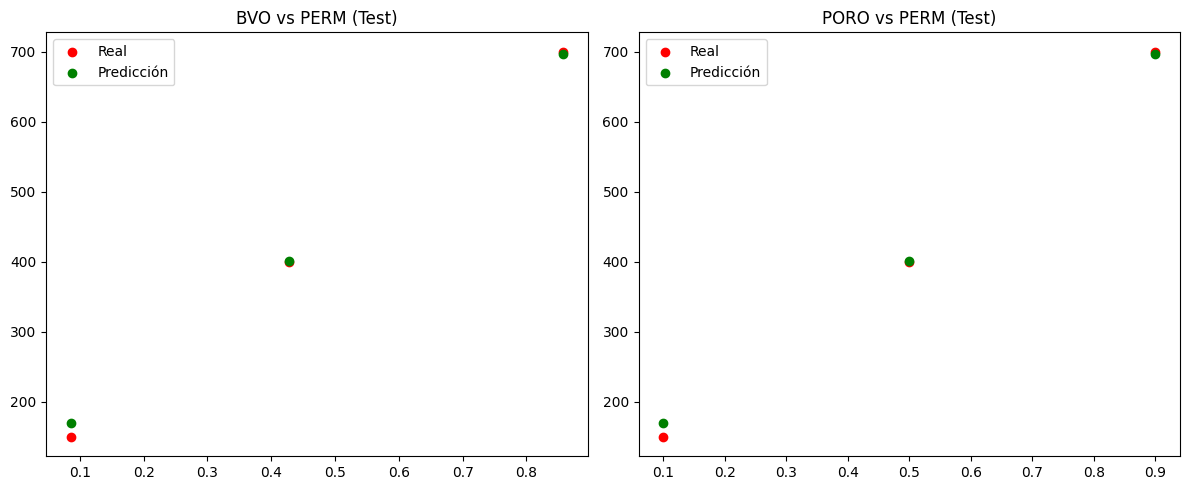

In [23]:
# Visualización de predicciones
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_test['BVO'], y_test, color='red', label='Real')
axes[0].scatter(X_test['BVO'], y_test_pred, color='green', label='Predicción')
axes[0].set_title('BVO vs PERM (Test)')
axes[0].legend()
axes[1].scatter(X_test['PORO'], y_test, color='red', label='Real')
axes[1].scatter(X_test['PORO'], y_test_pred, color='green', label='Predicción')
axes[1].set_title('PORO vs PERM (Test)')
axes[1].legend()
plt.tight_layout()
plt.show()
        

**Comentario:**
- Observé cómo se ajustaban las predicciones del modelo a los datos reales.
- Si los puntos verdes (predicción) se alineaban bien con los rojos (reales), consideré que el modelo predecía correctamente.
- Si había mucha dispersión, el modelo no estaba capturando bien la relación.

In [24]:
# Cambia hiperparámetros usando regresión Ridge
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
y_test_pred_ridge = ridge.predict(X_test)
print('RMSE Ridge Test:', np.sqrt(mean_squared_error(y_test, y_test_pred_ridge)))
        

RMSE Ridge Test: 196.54748357647546


**Comentario:**
- Cambié el hiperparámetro alpha y observé cómo afectaba el ajuste y el sobreajuste del modelo.
- Un alpha alto penalizaba más los coeficientes, lo que podía reducir el sobreajuste pero también disminuir la capacidad predictiva si era demasiado alto.
- Comparé el RMSE de Ridge con el de la regresión lineal simple para ver el efecto.

## 4. Entrenamiento del modelo y ajuste de hiperparámetros

a. Realiza validación cruzada K-fold para evaluar el modelo.
- La validación cruzada permite estimar el rendimiento del modelo de forma más robusta, usando diferentes particiones de los datos.
- Observa la variabilidad del RMSE entre los folds para evaluar la estabilidad del modelo.

In [25]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
print('RMSE promedio (CV):', -scores.mean())
        

RMSE promedio (CV): 5.7538924762379695


b. Ajuste de hiperparámetros usando GridSearchCV.
- GridSearchCV probó diferentes combinaciones de hiperparámetros y seleccionó la que daba mejor resultado según la métrica elegida.
- Comparé el RMSE y el alpha óptimo con los resultados anteriores.

In [26]:
from sklearn.model_selection import GridSearchCV
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid.fit(X, y)
print('Mejor alpha:', grid.best_params_['alpha'])
print('Mejor RMSE:', -grid.best_score_)
        

Mejor alpha: 0.01
Mejor RMSE: 14.905626707054264


c. BONUS 1: Función automática para todo el pipeline.
- Esta función realizó imputación, normalización, ajuste de hiperparámetros, validación cruzada y me devolvió el mejor modelo.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
def pipeline_automatica(X, y):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler()),
        ('reg', Ridge())
    ])
    param_grid = {'reg__alpha': [0.01, 0.1, 1, 10, 100]}
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_root_mean_squared_error')
    grid.fit(X, y)
    return grid.best_estimator_

# Uso:
modelo_final = pipeline_automatica(X, y)
        

d. BONUS 2: Uso de sklearn Pipeline para todo el flujo de trabajo.
- Pude agregar pasos adicionales al pipeline, como selección de características, transformación de variables, etc.
- El pipeline me facilitó la reproducibilidad y la automatización del flujo de trabajo de machine learning.